# Análise Exploratória de Dados — Segmentação Crédito

## Objetivo
Entender o perfil dos clientes.
identificando padrões e variáveis relevantes para a modelagem preditiva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregando os Dados

In [2]:
df = pd.read_csv('../data/raw/CC GENERAL.csv')
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")

Dataset carregado: 8950 linhas e 18 colunas


## 2. Primeiras Impressões

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.describe

<bound method NDFrame.describe of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANC

In [7]:
# Verificando nulos
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal de clientes: {len(df)}")

# Tratando nulos
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

print("\nApós tratamento:")
print(df.isnull().sum().sum(), "nulos restantes")

Valores nulos por coluna:
Series([], dtype: int64)

Total de clientes: 8950

Após tratamento:
0 nulos restantes


## 3. Distribuições e Outliers

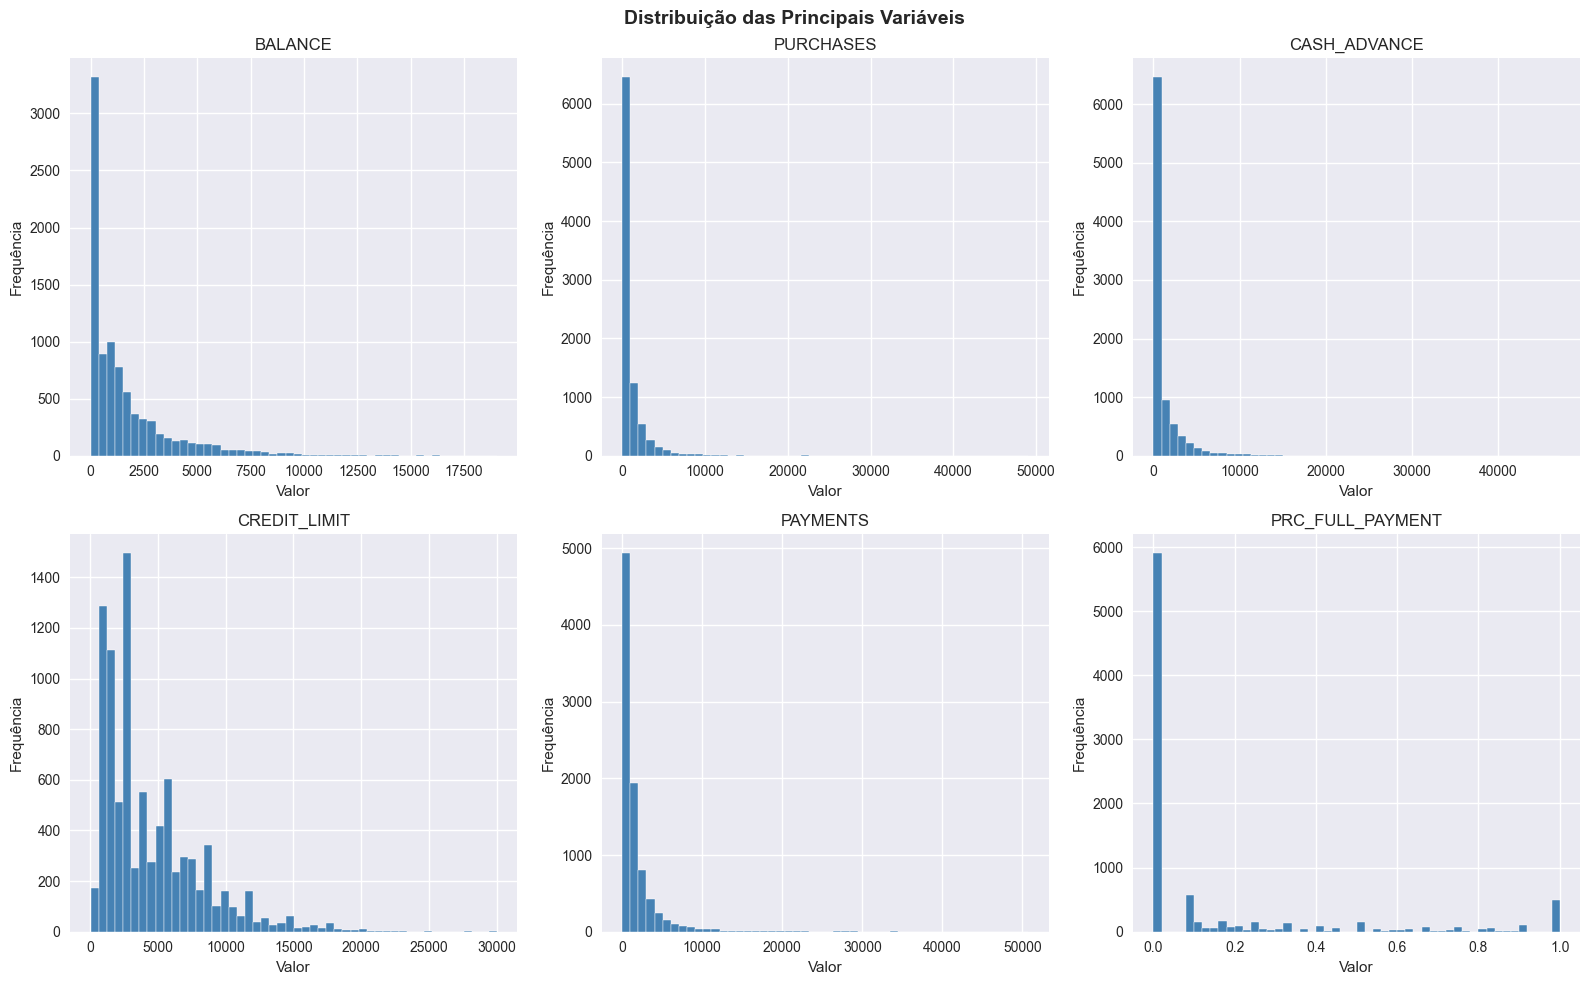

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
             'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Principais Variáveis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Correlações entre Variáveis

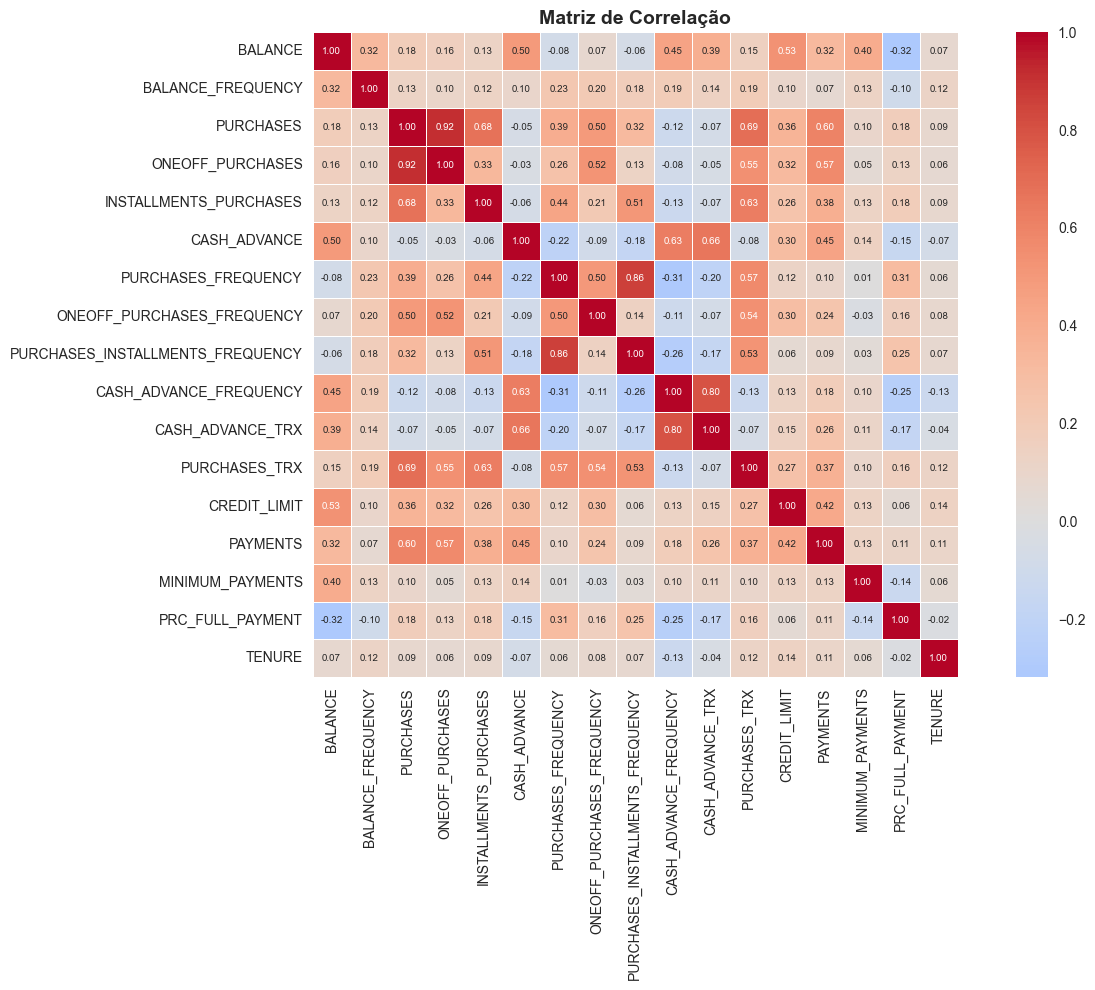

In [9]:
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['CUST_ID']).corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Insights Finais do EDA

In [10]:
print("""
PRINCIPAIS INSIGHTS DO EDA
===========================

1. DATASET: 8.950 clientes, 17 variáveis comportamentais
   → 2 colunas com nulos tratados (mediana)

2. DISTRIBUIÇÕES: Todas as variáveis financeiras são
   assimétricas à direita
   → Transformação logarítmica necessária antes do clustering

3. COMPORTAMENTO DE PAGAMENTO:
   → Maioria nunca paga fatura completa (PRC_FULL_PAYMENT ~ 0)
   → Pequeno grupo sempre quita tudo (PRC_FULL_PAYMENT = 1)
   → Sugere segmentos bem distintos

4. MULTICOLINEARIDADE IDENTIFICADA:
   → PURCHASES x ONEOFF_PURCHASES: 0.92
   → CASH_ADVANCE_FREQUENCY x CASH_ADVANCE_TRX: 0.80
   → PURCHASES_FREQUENCY x PURCHASES_INSTALLMENTS_FREQUENCY: 0.86
   → PCA necessário para reduzir redundância

5. DOIS PERFIS OPOSTOS JÁ VISÍVEIS:
   → Perfil COMPRADOR: alto PURCHASES, baixo CASH_ADVANCE
   → Perfil SACADOR: alto CASH_ADVANCE, baixo PURCHASES_FREQUENCY
   → Alto risco associado ao perfil sacador

6. PRÓXIMOS PASSOS:
   → Transformação logarítmica nas variáveis financeiras
   → Padronização (StandardScaler)
   → Redução de dimensionalidade (PCA)
   → Clustering (K-Means + DBSCAN)
""")


PRINCIPAIS INSIGHTS DO EDA

1. DATASET: 8.950 clientes, 17 variáveis comportamentais
   → 2 colunas com nulos tratados (mediana)

2. DISTRIBUIÇÕES: Todas as variáveis financeiras são
   assimétricas à direita
   → Transformação logarítmica necessária antes do clustering

3. COMPORTAMENTO DE PAGAMENTO:
   → Maioria nunca paga fatura completa (PRC_FULL_PAYMENT ~ 0)
   → Pequeno grupo sempre quita tudo (PRC_FULL_PAYMENT = 1)
   → Sugere segmentos bem distintos

4. MULTICOLINEARIDADE IDENTIFICADA:
   → PURCHASES x ONEOFF_PURCHASES: 0.92
   → CASH_ADVANCE_FREQUENCY x CASH_ADVANCE_TRX: 0.80
   → PURCHASES_FREQUENCY x PURCHASES_INSTALLMENTS_FREQUENCY: 0.86
   → PCA necessário para reduzir redundância

5. DOIS PERFIS OPOSTOS JÁ VISÍVEIS:
   → Perfil COMPRADOR: alto PURCHASES, baixo CASH_ADVANCE
   → Perfil SACADOR: alto CASH_ADVANCE, baixo PURCHASES_FREQUENCY
   → Alto risco associado ao perfil sacador

6. PRÓXIMOS PASSOS:
   → Transformação logarítmica nas variáveis financeiras
   → Padroniz